In [2]:

from one.api import ONE
from brainbox.population.decode import get_spike_counts_in_bins
from brainbox.io.one import SpikeSortingLoader, SessionLoader
from brainbox.ephys_plots import plot_brain_regions
from brainbox.behavior.wheel import velocity
from brainbox.task.trials import get_event_aligned_raster, get_psth
from iblatlas.atlas import AllenAtlas
from brainwidemap import bwm_query, load_good_units, load_trials_and_mask, bwm_units
from brainbox.behavior.training import compute_performance, plot_psychometric, plot_reaction_time
from brainbox.task.trials import find_trial_ids
from brainbox.io.one import SessionLoader
from pathlib import Path
from brainbox.task.trials import get_event_aligned_raster, get_psth
from brainbox import singlecell
import numpy as np
from iblatlas.atlas import BrainRegions
from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
import itertools
import pickle as pkl
from tqdm import tqdm
from pathlib import Path

from ibl_info.broja_pid import compute_pid, coinformation, compute_pid_unbiased
from ibl_info.utility import discretize_neural_data, subsample
from ibl_info.prepare_data_pid import gather_data_choice, gather_data_feedback, gather_data_stim, combine_probes, gather_data_prior
from ibl_info.load_glm_hmm import load_state_dataframe

In [3]:
one = ONE(base_url="https://openalyx.internationalbrainlab.org", password="international")
# eids = eids_df.eid

eids = np.load('D:\\personal\\phD\\code\\information-decomposition\\ibl-partial-info-decomp\\data\\processed\\eids_with_detailed_insertions.npy',allow_pickle=True)
eid = eids[0]

In [4]:
def load_action_kernel(eid):
    location = f'D:\\personal\\phD\\code\\information-decomposition\\ibl-partial-info-decomp\\data\\raw\\{eid}_actionkernel_prior.csv'
    df = pd.read_csv(location)
    return df['prior']

In [5]:
pids, probes = one.eid2pid(eid) # get pids



# load data
spikes_probe0, clusters_probe0 = load_good_units(one, pids[0], probes[0])
spikes_probe1, clusters_probe1 = load_good_units(one, pids[1], probes[1])

# don't combine until we send it to the pid calculations
brainreg = BrainRegions()    
clusters_probe0['Beryl'] = brainreg.acronym2acronym(clusters_probe0.acronym.values, mapping='Beryl')
clusters_probe1['Beryl'] = brainreg.acronym2acronym(clusters_probe1.acronym.values, mapping='Beryl')


# load trials and mask
session_l = SessionLoader(one=one, eid=eid)  
session_l.load_trials()

trials_df, trials_mask = load_trials_and_mask(one=one, eid=eid, sess_loader=session_l, min_rt=0.08, max_rt=2.0, nan_exclude='default', exclude_nochoice=True)

#load action kernel data
prior = load_action_kernel(eid)
trials_df['prior'] = prior
trials_df['prior-binary'] = np.asarray(trials_df['prior']>=0.5, dtype=np.int16)

#mask it
#subset trials based on trials_mask
trials_df = trials_df[trials_mask]

K = 2
trials_df_glm = load_state_dataframe(eid, K=K)
trials_df_glm['state'] = trials_df_glm[f'glm-hmm_{K}'].apply(lambda x: np.argmax(x))

#subset it
trials_df_glm = trials_df_glm[trials_mask]

In [6]:
(
    spike_count_stim_probe0, 
    spike_count_stim_probe1, 
    cluster_id_probe0, 
    cluster_id_probe1, 
    decoding_variable
) = gather_data_stim(trials_df, spikes_probe0, spikes_probe1)

regions_probe0 = clusters_probe0['Beryl'][cluster_id_probe0].to_numpy()
regions_probe1 = clusters_probe1['Beryl'][cluster_id_probe1].to_numpy()

# drop unwanted neurons
neural_data, regions = combine_probes(spike_count_stim_probe0, spike_count_stim_probe1, regions_probe0, regions_probe1, aggregate=False, average=False)

Neurons thrown away: ['root' 'root']
Neurons thrown away: ['root' 'root' 'root']


<Axes: >

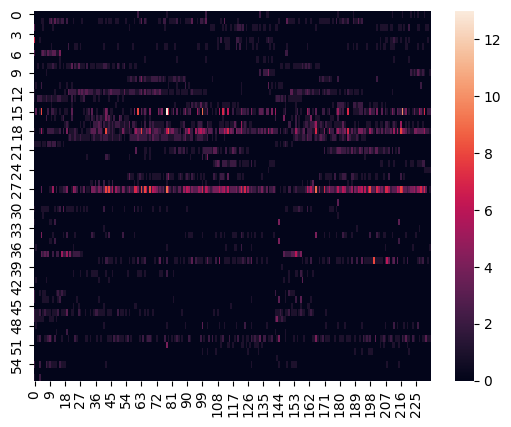

In [9]:
sns.heatmap(neural_data)

In [23]:
n_bins = 4

spike_counts = neural_data[1,:]

quantile_bins, bin_edges_p = pd.qcut(spike_counts, q=n_bins, labels=False, duplicates='drop', retbins=True)
hist, bin_edges = np.histogram(spike_counts, bins=n_bins)
uniform_bins = np.digitize(spike_counts, bins=bin_edges, right=False)

In [28]:
spike_counts.shape

(234,)

In [29]:
quantile_bins.shape

(234,)

In [31]:
uniform_bins.shape

(234,)

<Axes: >

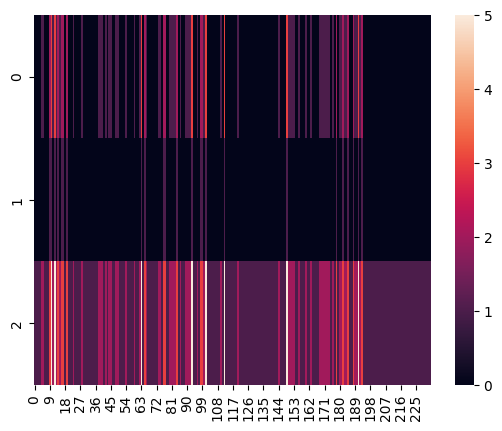

In [33]:
fig, ax = plt.subplots()
sns.heatmap(np.vstack([spike_counts, quantile_bins, uniform_bins]))


In [51]:
def discretize_neural_data(neural_data, method='neuron', n_bins=4):
    """
    Discretize the spike counts into equipopulated bins

    Args:
        neural_data (np.array): spike counts for neurons x trials
        method (str, optional): how to determine the percenille. 
                                Defaults to 'neuron'. Calculate the percentile per neuron
                                Other options: 'all': Calculate the percentile based on the entire dataset
    """
    print(neural_data.shape, method)
    if method=='neuron':
        discrete_data = np.zeros((neural_data.shape[0], neural_data.shape[1]))
        # discretize per recorded neuron
        for idx in tqdm(range(neural_data.shape[0])):

            row = neural_data[idx, :]
            # bin_edges = np.percentile(row, [20,40,60,80])
            # set bin edges to 4 parts
            #bin_edges = np.percentile(row, [25,50,75])
            # discrete_data[idx, :] = np.digitize(row, bin_edges)
            discrete_row, bin_edges_p = pd.qcut(row, q=n_bins, labels=False, duplicates='drop', retbins=True)
            discrete_data[idx, :] = discrete_row
    elif method=='all':
        bin_edges = np.percentile(neural_data, [20,40,60,80])
        # set bin edges to 4 parts
        #bin_edges = np.percentile(neural_data, [25,50,75])
        # discrete_data = np.digitize(neural_data, bin_edges)
        flat = neural_data.flatten()
        discrete_data_flat, bin_edges_p = pd.qcut(flat, q=n_bins, labels=False, duplicates='drop', retbins=True)
        discrete_data = discrete_data_flat.reshape(neural_data.shape)
    elif method=='none':
        return neural_data
    else:
        raise NotImplementedError
    
    # replace nan rows with 0
    discrete_data = np.nan_to_num(discrete_data, nan=0)
    return discrete_data

In [52]:
discrete_data_neuron = discretize_neural_data(neural_data, 'neuron')
discrete_data_all = discretize_neural_data(neural_data, 'all')

(57, 234) neuron


100%|██████████| 57/57 [00:00<00:00, 1376.53it/s]

(57, 234) all


<Axes: >

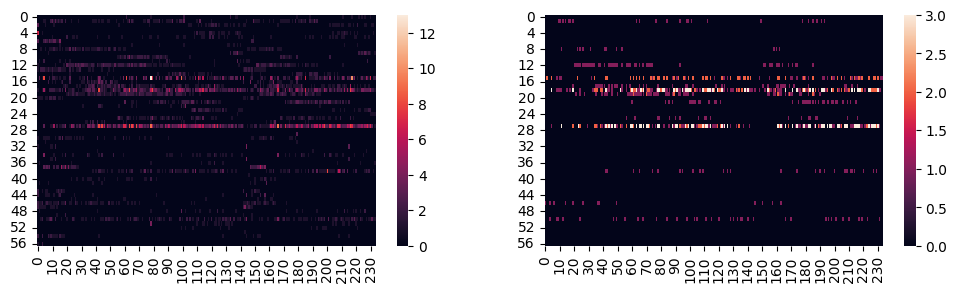

In [54]:
fig, ax = plt.subplots(ncols=2,figsize=(12,3))

sns.heatmap(neural_data, ax=ax[0])
sns.heatmap(discrete_data_neuron, ax=ax[1])

In [48]:
discrete_data_neuron[28,:]

array([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, na

In [50]:
discrete_data_all

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=int64)

In [30]:
bin_edges

array([0., 0., 0., 0.])

(array([220.,   0.,   0.,   0.,   0.,  11.,   0.,   0.,   0.,   3.]),
 array([0. , 0.2, 0.4, 0.6, 0.8, 1. , 1.2, 1.4, 1.6, 1.8, 2. ]),
 <BarContainer object of 10 artists>)

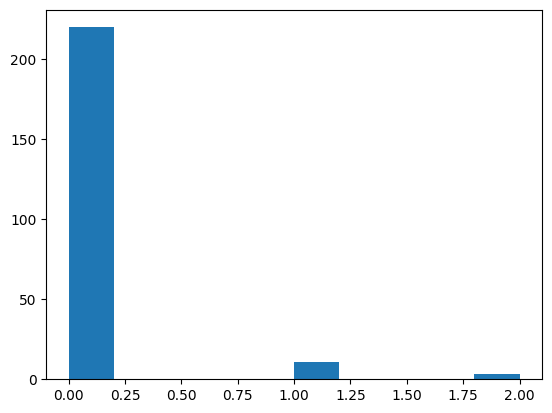

In [32]:
plt.hist(row)